## Step 1 — Load Data
Loading Titanic dataset and doing initial exploration to understand shape, types and basic statistics.

In [76]:
import seaborn as sns
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [77]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [78]:
# Getting number of rows and columns with shape -891 rows,15 columns
df.shape

(891, 15)

In [79]:
# Getting info of the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [80]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 2 — Handling Missing Values
Identifying columns with missing values and deciding how to handle each:
- age: filled with mean (mean and median were close — 29 vs 28)
- embark_town: filled with mode (only 2 missing)
- deck: dropped (77% missing — filling would corrupt data)

In [81]:
# Finding the number of null values in each columns
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [82]:
# Filling the string values of embark town with the moset frequent appearnce i.e with mode()
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [83]:
# Finding the mean and median to find which to use to fill null values
df["age"].mean()

29.69911764705882

In [84]:
df["age"].median()
# as there is not much diff between the two we can use the mean if there was diff use median 

28.0

In [85]:
df["age"]=df["age"].fillna(df["age"].mean())

In [86]:
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [87]:
# Dropping the deck as it has 688 out of 891 values as null 
df=df.drop(columns=["deck"])

In [88]:
# checkin ghte null values again
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [89]:
# checkin the datatypes of the columns 
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

## Step 3 — Data Types & Feature Selection
Fixing wrong data types and removing redundant columns that carry 
duplicate information:
- alive: duplicate of survived (data leakage)
- class: duplicate of pclass
- who: derived from sex + age
- adult_male: derived from sex + age
- embark_town: duplicate of embarked

In [90]:
# Feature selecting dropping the columns with now use 
df=df.drop(columns=['class','who','adult_male','alive','embark_town'])

In [91]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [92]:
df.shape

(891, 9)

## Step 4 — Removing Duplicates
Checking and removing duplicate rows to avoid model bias.

In [93]:
#Removing the duplicates
df.duplicated().sum()

111

In [94]:
df=df.drop_duplicates()

In [95]:
df.duplicated().sum()

0

## Step 5 — Outlier Detection & Removal
Identifying continuous numeric columns and removing outliers using 
the IQR method (1.5 × IQR rule).
- age: mild outliers above 55
- fare: heavy outliers — extreme values up to 500+
- Dataset reduced from 891 to 650 rows after removal

In [96]:
#finding and removing outliers
num_cols = df.select_dtypes(include='number').columns.tolist()
outlier_cols = [col for col in num_cols if df[col].nunique() > 10]
print(outlier_cols)

['age', 'fare']


In [97]:
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [98]:
df.shape

(650, 9)

In [99]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.000000,1,0,7.2500,S,False
2,1,3,female,26.000000,0,0,7.9250,S,True
3,1,1,female,35.000000,1,0,53.1000,S,False
4,0,3,male,35.000000,0,0,8.0500,S,True
5,0,3,male,29.699118,0,0,8.4583,Q,True


## Step 6 — Encoding Categorical Variables
Converting text columns to numbers for model compatibility:
- sex: binary column → map (male=1, female=0)
- embarked: nominal 3 categories → one-hot encoding (drop_first=True)
- alone: bool → converted to int (0/1)

In [100]:
#Encoding the data
df.select_dtypes(include='object').columns

Index(['sex', 'embarked'], dtype='object')

In [101]:
df["sex"]=df["sex"].map({"male":1,"female":0})

In [102]:
df['alone'] = df['alone'].astype(int)


In [103]:
import pandas as pd
df=pd.get_dummies(df,columns=["embarked"],drop_first=True,dtype=int)
 

In [104]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.000000,1,0,7.2500,0,0,1
2,1,3,0,26.000000,0,0,7.9250,1,0,1
3,1,1,0,35.000000,1,0,53.1000,0,0,1
4,0,3,1,35.000000,0,0,8.0500,1,0,1
5,0,3,1,29.699118,0,0,8.4583,1,1,0


## Step 7 — Train Test Split & Feature Scaling
Splitting data before scaling to prevent data leakage.
Applied StandardScaler on training data only — fit_transform on train, 
transform only on test.
- Test size: 20%
- Random state: 42

In [105]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=["survived"])
y=df["survived"]

In [106]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
# dping scaling making the each column of equal importance or brign at same range
from sklearn.preprocessing import StandardScaler
num_cols=X_train.select_dtypes(include="number").columns

scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [108]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.000000,1,0,7.2500,0,0,1
2,1,3,0,26.000000,0,0,7.9250,1,0,1
3,1,1,0,35.000000,1,0,53.1000,0,0,1
4,0,3,1,35.000000,0,0,8.0500,1,0,1
5,0,3,1,29.699118,0,0,8.4583,1,1,0


## Step 8 — Visualizations

### 8.1 Correlation Heatmap
Identifying which features have strongest relationship with survival target.

### 8.2 Feature Distributions
Understanding the shape and spread of each important feature.

### 8.3 Feature vs Target
How each feature impacts survival rate.

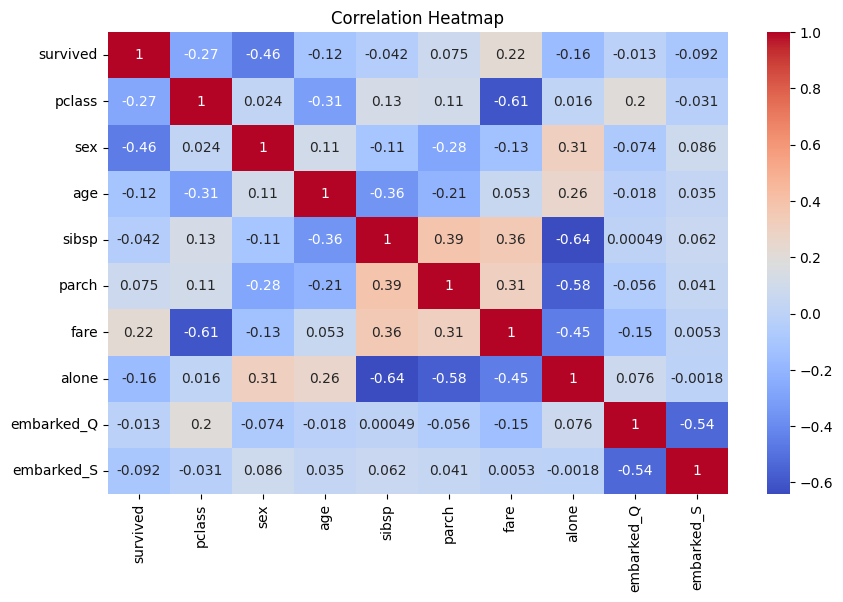

In [109]:
#Graph or Visuliation
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [110]:
corr_with_target = df.corr()['survived'].abs().sort_values(ascending=False) #.abs() remove +,- sign
important_features = corr_with_target[corr_with_target > 0.1].index.tolist()
important_features.remove('survived')
print(important_features)

['sex', 'pclass', 'fare', 'alone', 'age']


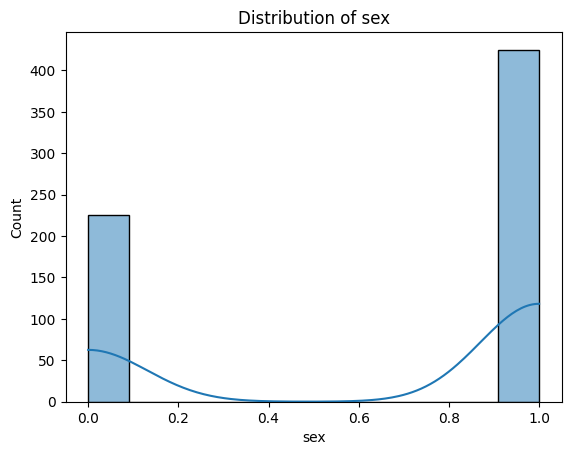

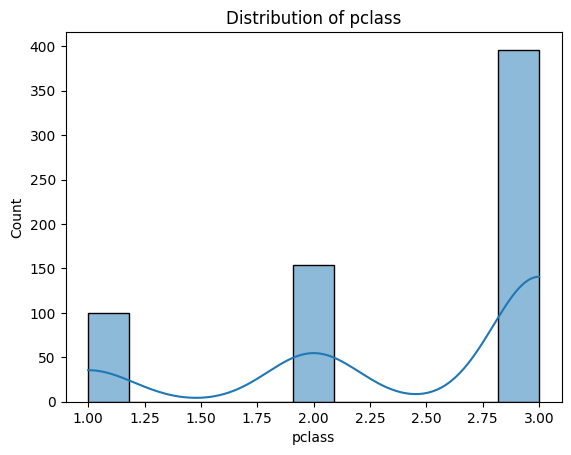

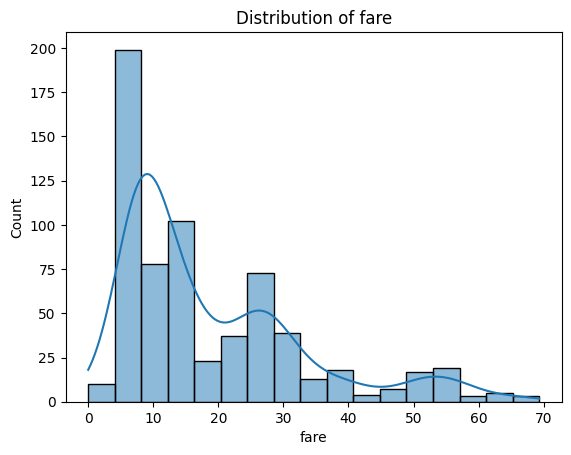

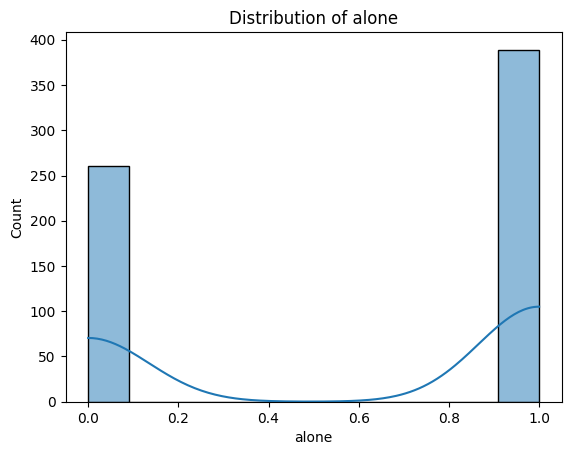

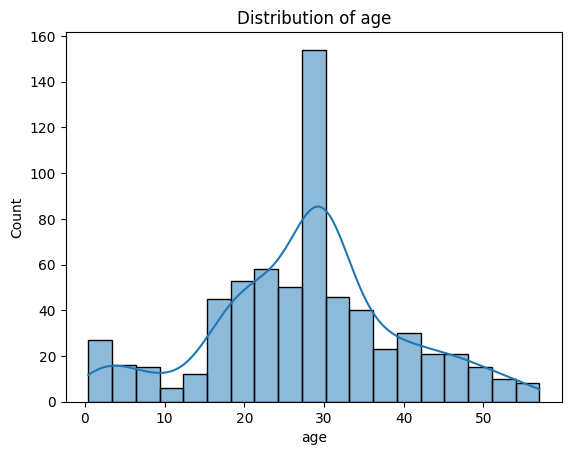

In [111]:
for cols in important_features:
    sns.histplot(df[cols],kde=True)
    plt.title(f"Distribution of {cols}")
    plt.show()

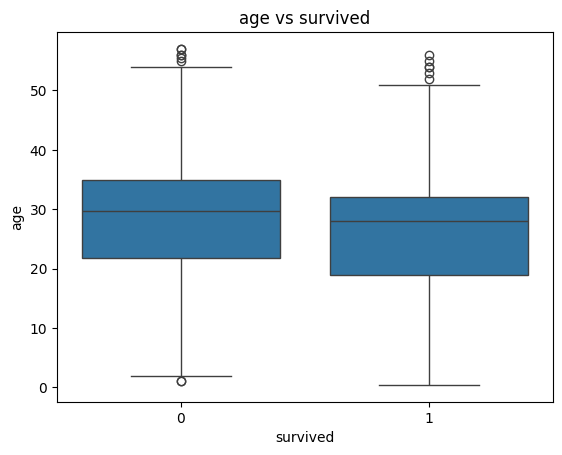

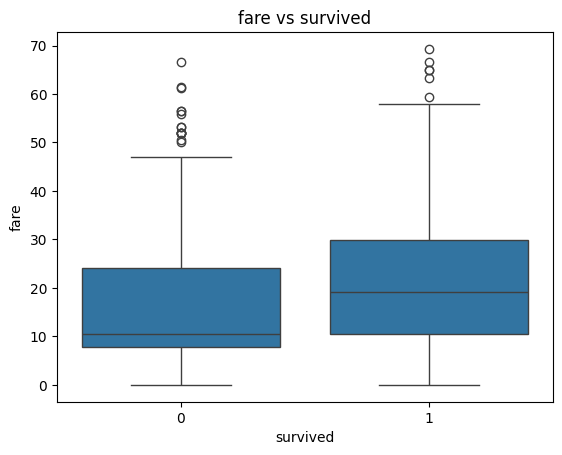

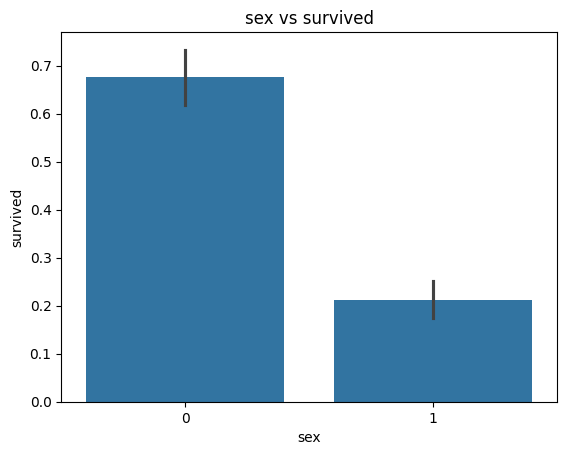

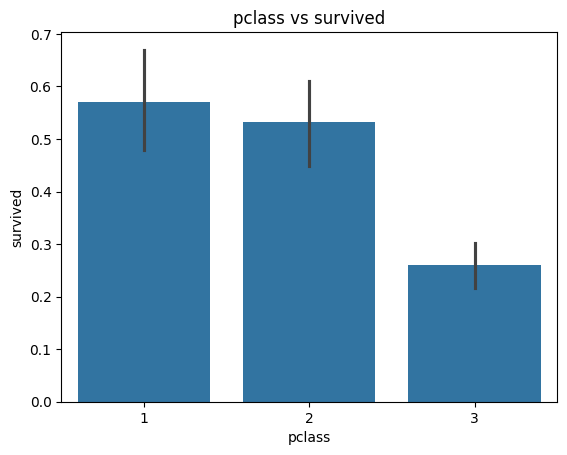

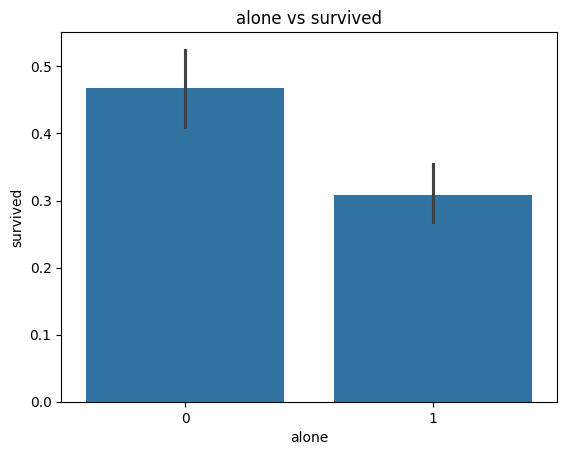

In [112]:
# Continuous features vs target
for col in ['age', 'fare']:
    sns.boxplot(x=df['survived'], y=df[col])
    plt.title(f'{col} vs survived')
    plt.show()

# Categorical/binary features vs target
for col in ['sex', 'pclass', 'alone']:
    sns.barplot(x=df[col], y=df['survived'])
    plt.title(f'{col} vs survived')
    plt.show()

## Key Findings & Observations

1. **Sex** — strongest predictor. Females survived at 68% vs males at 21%.
   "Women and children first" policy clearly visible in data.

2. **Pclass** — clear pattern. 1st class 57% survival vs 3rd class 26%.
   Higher class = better lifeboat access.

3. **Fare** — survivors paid higher median fare (~20) vs non-survivors (~10).
   Directly linked to passenger class.

4. **Age** — weak predictor (correlation 0.12). Slight trend — 
   younger passengers survived marginally more.

5. **Alone** — passengers traveling alone had lower survival rate.

## Conclusion
Sex, Pclass, and Fare are the top 3 features for predicting survival.
These will be the most important features when building an ML model on this dataset.

In [113]:
import os
os.getcwd()

'C:\\Users\\taran\\aiml(steps ahead)'